In [1]:
import pickle

from scipy.spatial.distance import cdist

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import FIG_DIR


atlep1 = Episode('atlep1')
participants = Participant.load_all()

ep_events_centered = atlep1.events - atlep1.events.mean(axis=0)

eventseg_all_data = {}

for p in participants:
    imm_traj_centered = p.trajectories['atlep1'] - p.trajectories['atlep1'].mean(axis=0)
    del_traj_centered = p.trajectories['delayed'] - p.trajectories['delayed'].mean(axis=0)
    
    imm_sim_timeseries = 1 - cdist(imm_traj_centered, ep_events_centered, 'cosine')
    del_sim_timeseries = 1 - cdist(del_traj_centered, ep_events_centered, 'cosine')
    
    imm_event_matches = p.event_matches['atlep1']
    del_event_matches = p.event_matches['delayed']
    
    imm_event_bounds = p.event_bounds['atlep1']
    del_event_bounds = p.event_bounds['delayed']
    
    eventseg_all_data[f'P{p.sub_n}'] = {
        'imm_sim_timeseries': imm_sim_timeseries,
        'del_sim_timeseries': del_sim_timeseries,
        'imm_event_matches': imm_event_matches,
        'del_event_matches': del_event_matches,
        'imm_event_bounds': imm_event_bounds,
        'del_event_bounds': del_event_bounds
    }
    
# with open('eventseg_all_data.p', 'wb') as f:
#     pickle.dump(eventseg_all_data, f)

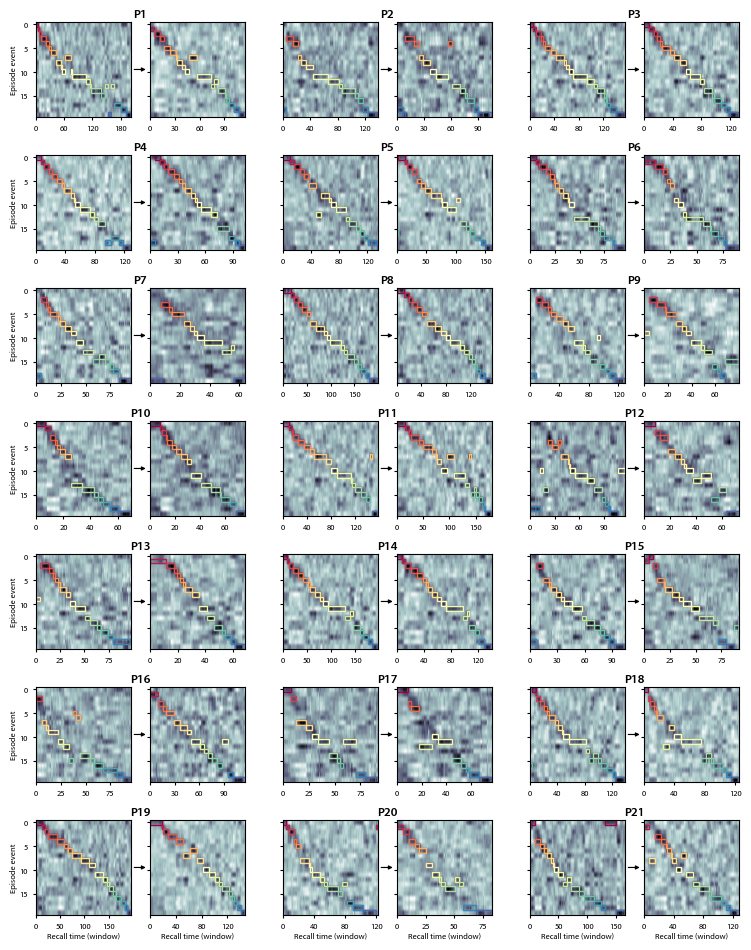

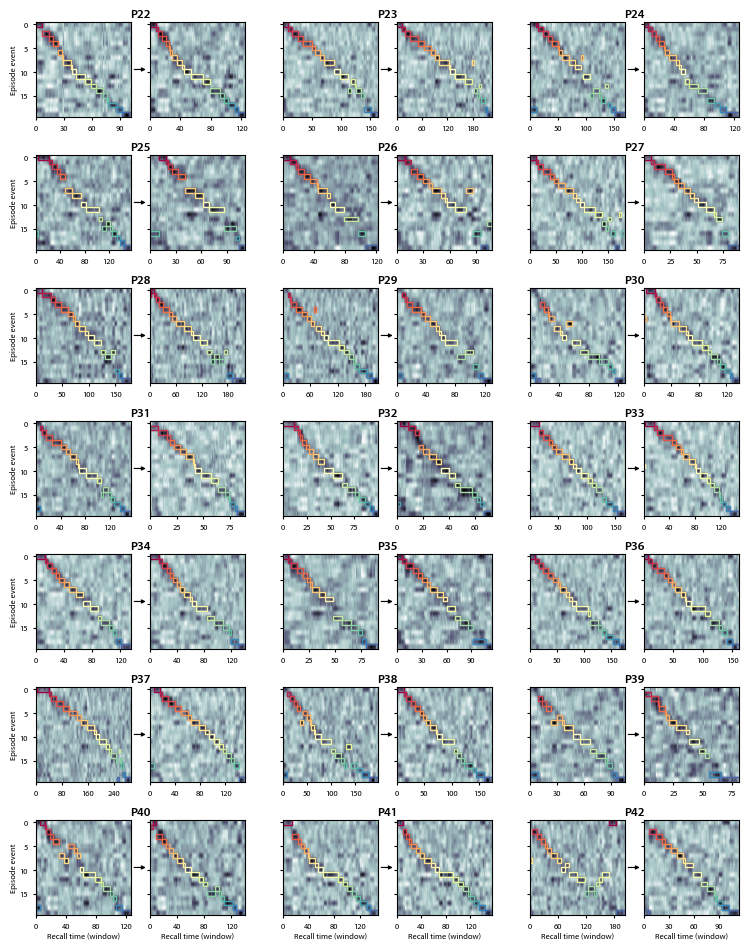

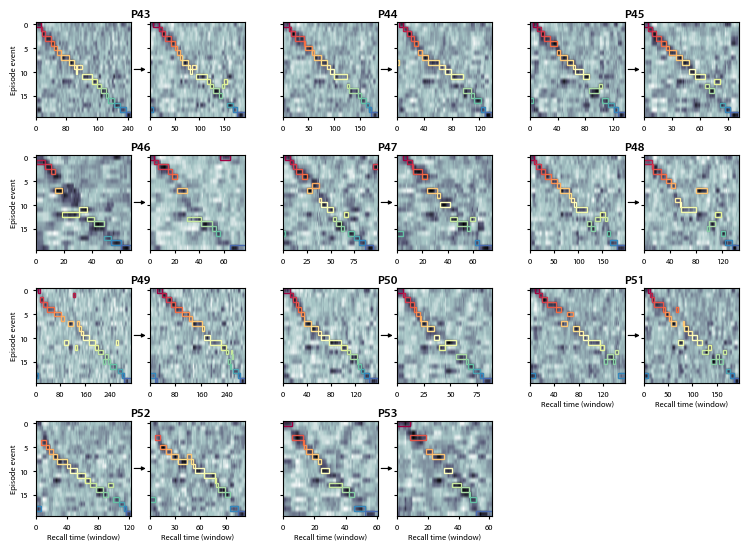

In [2]:
# IMPORTS
import math
import pickle

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch, Rectangle
from matplotlib.ticker import MaxNLocator, MultipleLocator


# LOAD DATA
with open('eventseg_all_data.p', 'rb') as f:
    eventseg = pickle.load(f)

# CONSTANTS
HEATMAP_CMAP = plt.cm.bone_r        # similarity heatmaps
EVENT_CMAP = plt.cm.Spectral        # event-boundary rectangles, keyed to episode event
N_EPISODE_EVENTS = 20               # episode events = y-dim of each similarity matrix

RECT_LINEWIDTH = 1                   # event-boundary rectangle linewidth
HEATMAP_LABEL_FONTSIZE = 6           # axis labels ("Episode event" / "Recall time (window)")
HEATMAP_TICKLABEL_FONTSIZE = 6       # tick labels
TICK_LENGTH = 2                      # tick-mark length (points)
AXES_TITLE_FONTSIZE = 9              # per-pair "P<N>" label

# --- Layout (based on the multi-page 2D paths grid) --------------------------
# 3 pairs (immediate + delayed) per row, 6 rows per page, paginated across as
# many pages as needed. Everything is in units of one recall panel (1x1); the
# figure size is derived so panels stay physically square.
#
# Gaps are 2x those of the 2D paths grid (relative sizes preserved), enlarged so
# (a) the row gap clears the pair labels above each row's x tick-labels, and
# (b) the pair gap has room for the immediate->delayed arrow.
PAIRS_PER_ROW = 3
ROWS_PER_PAGE = 7
PANEL_IN = 0.95          # side length of one recall panel (inches)
PAIR_GAP = 0.2          # horizontal gap within an immediate+delayed pair
GROUP_GAP = 0.4         # horizontal gap between pairs
ROW_GAP = 0.4           # vertical gap above each row (holds the pair label)

# immediate -> delayed arrow, drawn within the pair gap (sizes scaled to the
# panel, matching the 2D paths grid)
GRID_SCALE = PANEL_IN / 3.4
PAIR_ARROW_COLOR = 'k'
PAIR_ARROW_LINEWIDTH = 3 * GRID_SCALE
PAIR_ARROW_HEAD_SCALE = 20 * GRID_SCALE     # arrowhead size (points)
PAIR_ARROW_LENGTH_FRAC = 0.9               # shaft length as a fraction of the pair gap


# ============================== HELPERS ================================
ALL_PARTICIPANTS = sorted(eventseg, key=lambda s: int(s[1:]))  # P1..P53


def draw_heatmap(axes, sim, bounds, matches):
    """Heatmap of the recall-timepoint x episode-event similarity matrix, with a
    rectangle drawn around each decoded recall event (colored by its matched
    episode event). `sim` is (n_timepoints, n_episode_events)."""
    n_timepoints, n_events = sim.shape
    # episode events on y, recall time on x; square via aspect = time / events
    axes.imshow(sim.T, cmap=HEATMAP_CMAP, aspect=n_timepoints / n_events)
    for (onset, offset), match_ix in zip(bounds, matches):
        axes.add_patch(Rectangle(
            (onset - 0.5, match_ix - 0.5),
            width=offset - onset + 1, height=1,
            linewidth=RECT_LINEWIDTH,
            edgecolor=EVENT_CMAP(match_ix / N_EPISODE_EVENTS),
            facecolor='none'))


def style_heatmap(axes, is_leftmost, is_bottom):
    """Ticks on all panels; y tick-labels + label only on the leftmost panel of a
    row; x tick-labels everywhere; x label only on the bottom row."""
    axes.xaxis.set_major_locator(MaxNLocator(nbins=4, integer=True))
    axes.yaxis.set_major_locator(MultipleLocator(5))
    axes.tick_params(labelsize=HEATMAP_TICKLABEL_FONTSIZE, length=TICK_LENGTH)
    if is_leftmost:
        axes.set_ylabel('Episode event', fontsize=HEATMAP_LABEL_FONTSIZE, labelpad=1)
    else:
        axes.tick_params(labelleft=False)
    if is_bottom:
        axes.set_xlabel('Recall time (window)', fontsize=HEATMAP_LABEL_FONTSIZE, labelpad=1)


# column left-edges (panel units): [imm0, del0, imm1, del1, imm2, del2]
COL_X = []
for j in range(PAIRS_PER_ROW):
    base = j * (2 + PAIR_GAP + GROUP_GAP)
    COL_X.extend([base, base + 1 + PAIR_GAP])

# row top-edges (panel units), measured downward from the top of the figure
ROW_Y = [(r + 1) * ROW_GAP + r for r in range(ROWS_PER_PAGE)]

TOTAL_W = PAIRS_PER_ROW * (2 + PAIR_GAP) + (PAIRS_PER_ROW - 1) * GROUP_GAP
TOTAL_H = ROWS_PER_PAGE * (1 + ROW_GAP)
FIG_W = TOTAL_W * PANEL_IN
FIG_H = TOTAL_H * PANEL_IN

PER_PAGE = PAIRS_PER_ROW * ROWS_PER_PAGE
N_PAGES = math.ceil(len(ALL_PARTICIPANTS) / PER_PAGE)


def cell(x_left, y_top, w, h):
    """Panel-unit rectangle (x from the left, y downward from the top) ->
    Matplotlib [left, bottom, width, height] figure-fraction rectangle."""
    return [x_left / TOTAL_W,
            (TOTAL_H - y_top - h) / TOTAL_H,
            w / TOTAL_W,
            h / TOTAL_H]


# ============================== FIGURES ================================
lets = ('A', 'B', 'C')
for page in range(N_PAGES):
    page_ids = ALL_PARTICIPANTS[page * PER_PAGE:(page + 1) * PER_PAGE]
    max_row = (len(page_ids) - 1) // PAIRS_PER_ROW  # bottom row on this page

    fig = plt.figure(figsize=(FIG_W, FIG_H))
    fig.patch.set_alpha(0)

    # x-axis label goes on the bottom-most panel of each column. When the last
    # row is short, columns without a panel there get labeled one row up.
    last_row_count = len(page_ids) - max_row * PAIRS_PER_ROW

    def is_bottom(row, col_pair):
        bottom_row = max_row if col_pair < last_row_count else max_row - 1
        return row == bottom_row

    pair_axes = []  # (sid, ax_immediate, ax_delayed)
    for i, sid in enumerate(page_ids):
        row, col_pair = divmod(i, PAIRS_PER_ROW)
        y = ROW_Y[row]
        p = eventseg[sid]
        bottom = is_bottom(row, col_pair)

        ax_imm = fig.add_axes(cell(COL_X[2 * col_pair], y, 1, 1))
        draw_heatmap(ax_imm, p['imm_sim_timeseries'],
                     p['imm_event_bounds'], p['imm_event_matches'])
        style_heatmap(ax_imm, is_leftmost=(col_pair == 0), is_bottom=bottom)
#         n_events = len(p['imm_event_matches'])
#         ax_imm.set_title(f'$K = {n_events}$', fontsize=HEATMAP_LABEL_FONTSIZE, pad=0)

        ax_del = fig.add_axes(cell(COL_X[2 * col_pair + 1], y, 1, 1))
        draw_heatmap(ax_del, p['del_sim_timeseries'],
                     p['del_event_bounds'], p['del_event_matches'])
        style_heatmap(ax_del, is_leftmost=False, is_bottom=bottom)
#         n_events = len(p['del_event_matches'])
#         ax_del.set_title(f'$K = {n_events}$', fontsize=HEATMAP_LABEL_FONTSIZE, pad=0)

        pair_axes.append((sid, ax_imm, ax_del))

    fig.canvas.draw()  # finalize axis positions before reading them

    # per-pair "P<N>" label, centered just above each pair
    for sid, ax_imm, ax_del in pair_axes:
        box_imm = ax_imm.get_position()
        box_del = ax_del.get_position()
        center_x = (box_imm.x0 + box_del.x1) / 2
        top_y = max(box_imm.y1, box_del.y1)
        fig.text(center_x, top_y + 0.003, sid, ha='center', va='bottom',
                 fontsize=AXES_TITLE_FONTSIZE, fontweight='semibold')

    # immediate -> delayed arrow, centered in each pair's gap
    for sid, ax_imm, ax_del in pair_axes:
        box_imm = ax_imm.get_position()
        box_del = ax_del.get_position()
        y = (box_imm.y0 + box_imm.y1) / 2
        gap_center = (box_imm.x1 + box_del.x0) / 2
        half_len = (box_del.x0 - box_imm.x1) * PAIR_ARROW_LENGTH_FRAC / 2
        fig.add_artist(FancyArrowPatch(
            (gap_center - half_len, y), (gap_center + half_len, y),
            transform=fig.transFigure, arrowstyle='-|>',
            mutation_scale=PAIR_ARROW_HEAD_SCALE, linewidth=PAIR_ARROW_LINEWIDTH,
            color=PAIR_ARROW_COLOR, clip_on=False))

#     plt.savefig(FIG_DIR / f'recall-eventseg-all-{lets[page]}-kvals.pdf', bbox_inches='tight')
    plt.show()
#     break